# 06 — Modelo Federado (Parte B)
## Aprendizaje federado entre tres bancos · PLUS TI – Universidad del Valle 2025

**Objetivo:** entrenar con los datasets etiquetados de **Banco 1 (BO-VIP)** y **Banco 2 (BR-PRIVATE)** e inferir sobre **Banco 3 (GT-STATE)**, que **no contiene la variable objetivo** `is_fraud`.

**Reto:** los tres bancos tienen distribuciones muy distintas (país, perfil de cliente, tipologías de fraude) → escenario **no-IID**. Un modelo entrenado en un solo banco generaliza mal al resto.

**Enfoque de federación (privacy-preserving):** cada banco entrena un modelo **localmente sobre sus propios datos** (los datos crudos nunca se comparten); solo se combinan las **salidas** de los modelos. Como LightGBM es un ensemble de árboles (no admite *FedAvg* de pesos como una red neuronal), la agregación federada natural es un **ensemble ponderado de probabilidades** de los modelos locales.

Comparamos cuatro escenarios:
| Modelo | Datos usados | Privacidad |
|---|---|---|
| Local B1 | solo Banco 1 | ✅ |
| Local B2 | solo Banco 2 | ✅ |
| **Federado** | ensemble B1+B2 (solo salidas) | ✅ |
| Centralizado | datos B1+B2 agrupados | ❌ (referencia / cota superior) |

## 1. Importaciones y configuración

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data" / "raw").exists() else Path.cwd().parent
RAW_DIR  = PROJECT_ROOT / "data" / "raw"
RESULTS  = PROJECT_ROOT / "results"; RESULTS.mkdir(exist_ok=True)

BANKS = {
    "B1_BO": "01_bo_vip_seed22_n100000.csv",
    "B2_BR": "02_br_privado_seed33_n100000.csv",
    "B3_GT": "03_gt_estatal_seed3_n100000.csv",
}
HOTEL_MCCS = [7011]
print("LightGBM:", lgb.__version__)
print("Raw dir :", RAW_DIR)

LightGBM: 4.6.0
Raw dir : /Users/davisroldanordonez/Universidad/security-science/Proyecto2-SecurityDS-PlusTI/data/raw


## 2. Ingeniería de variables reutilizable (sin *leakage*)

La misma función se aplica a los **tres** bancos para garantizar un espacio de features idéntico. Reproduce las variables clave de los notebooks 01–02 (ratios de monto, historial del cliente, velocidad, cambio de país y features de hospedaje), todas calculadas **solo con información anterior a cada transacción** (cero look-ahead) y **sin variables post-autorización** (`approved`, `DE39`, `DE38`, etc. quedan excluidas).

In [2]:
def engineer(path):
    """Pipeline de features leakage-free aplicable a cualquier banco."""
    d = pd.read_csv(RAW_DIR / path, sep=";")
    d["dt"] = pd.to_datetime(d["DE7_transmission_datetime"].astype(str).str.zfill(10),
                             format="%m%d%H%M%S", errors="coerce")
    d["month"] = d["dt"].dt.month
    d = d.sort_values(["client_id", "dt"]).reset_index(drop=True)
    d["is_hotel"] = d["DE18_merchant_category_code"].isin(HOTEL_MCCS)

    # Ratios de monto vs baseline del cliente
    d["amount_baseline_ratio"] = np.where(d["client_baseline_amount"] > 0,
                                           d["amount_usd"] / d["client_baseline_amount"], np.nan)
    d["amount_vs_baseline"] = d["amount_usd"] - d["client_baseline_amount"]

    # Historial del cliente (cumsum - actual = solo anteriores)
    g = d.groupby("client_id")
    d["client_txn_count_before"] = g.cumcount()
    cs = g["amount_usd"].cumsum()
    d["client_avg_amount_before"] = (cs - d["amount_usd"]) / d["client_txn_count_before"].replace(0, np.nan)
    d["client_std_amount_before"] = g["amount_usd"].transform(lambda x: x.expanding().std().shift(1))
    d["amount_vs_hist_avg"] = d["amount_usd"] / d["client_avg_amount_before"].replace(0, np.nan)
    ii = d["is_international"].astype(int); ci = ii.groupby(d["client_id"]).cumsum()
    d["client_intl_rate_before"] = (ci - ii) / d["client_txn_count_before"].replace(0, np.nan)

    # Velocidad temporal
    d["_prev"] = g["dt"].shift(1)
    d["hours_since_last_txn"] = ((d["dt"] - d["_prev"]).dt.total_seconds() / 3600).fillna(-1)
    d["is_rapid_succession"] = ((d["hours_since_last_txn"] >= 0) & (d["hours_since_last_txn"] < 1)).astype(int)

    # Cambio rápido de país (impossible travel)
    d["_pc"] = g["DE19_acquirer_country_code"].shift(1)
    d["rapid_country_change"] = ((d["DE19_acquirer_country_code"] != d["_pc"]) &
                                 (d["hours_since_last_txn"] >= 0) & (d["hours_since_last_txn"] < 24)).astype(int)

    # Features de hospedaje (Parte A)
    H = d["is_hotel"].astype(int)
    d["hotel_pos_anomaly"] = (d["is_hotel"] &
        ((d["channel"] == "POS") | (d["DE22_pos_entry_mode"].isin([51, 71])))).astype(int)
    d["hotel_x_amount_ratio"] = H * d["amount_baseline_ratio"].fillna(0)
    d["hotel_x_amount_usd"]   = H * d["amount_usd"]
    d["hotel_x_distance"]     = H * d["distance_from_home_km"].fillna(0)
    d["is_night"] = d["hour_local"].between(0, 4).astype(int)

    return d.drop(columns=["_prev", "_pc"])

print("Procesando los 3 bancos (puede tardar ~30s)...")
banks = {k: engineer(v) for k, v in BANKS.items()}
for k, d in banks.items():
    lab = "sin etiqueta" if d["is_fraud"].isna().all() else f"fraude={d['is_fraud'].mean()*100:.2f}%"
    print(f"  {k}: {len(d):,} filas | meses {sorted(d['month'].dropna().unique().astype(int))} | {lab}")

Procesando los 3 bancos (puede tardar ~30s)...
  B1_BO: 100,003 filas | meses [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)] | fraude=4.92%
  B2_BR: 100,000 filas | meses [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)] | fraude=3.21%
  B3_GT: 100,000 filas | meses [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)] | sin etiqueta


## 3. Análisis de *distribution shift* (escenario no-IID)

Antes de federar, evidenciamos que los tres bancos son estadísticamente distintos. Esto justifica por qué un solo modelo local no basta y por qué la federación (que combina conocimiento de varios bancos) ayuda a generalizar.

,n,fraude_%,monto_mediano,internacional_%,hotel_%,canal_top,ECOM_%,ATM_%
B1_BO,100003,4.92,200.4,23.4,9.1,ECOM,46.3,9.7
B2_BR,100000,3.2,80.3,13.0,3.6,POS,35.6,15.2
B3_GT,100000,NaN,13.7,4.0,1.4,POS,14.3,30.0


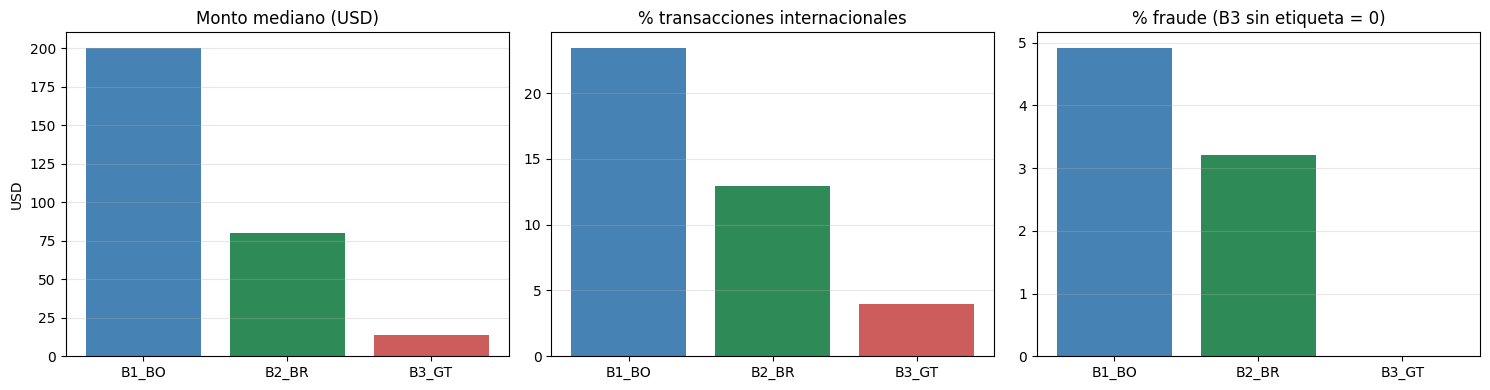

In [3]:
shift = pd.DataFrame({
    k: {
        "n": len(d),
        "fraude_%": round(d["is_fraud"].mean()*100, 2) if d["is_fraud"].notna().any() else np.nan,
        "monto_mediano": round(d["amount_usd"].median(), 1),
        "internacional_%": round(d["is_international"].mean()*100, 1),
        "hotel_%": round(d["is_hotel"].mean()*100, 1),
        "canal_top": d["channel"].mode()[0],
        "ECOM_%": round((d["channel"]=="ECOM").mean()*100, 1),
        "ATM_%": round((d["channel"]=="ATM").mean()*100, 1),
    } for k, d in banks.items()
}).T
display(shift)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
names = list(banks.keys())
axes[0].bar(names, [banks[k]["amount_usd"].median() for k in names], color=["steelblue","seagreen","indianred"])
axes[0].set_title("Monto mediano (USD)"); axes[0].set_ylabel("USD")
axes[1].bar(names, [banks[k]["is_international"].mean()*100 for k in names], color=["steelblue","seagreen","indianred"])
axes[1].set_title("% transacciones internacionales")
fr = [banks[k]["is_fraud"].mean()*100 if banks[k]["is_fraud"].notna().any() else 0 for k in names]
axes[2].bar(names, fr, color=["steelblue","seagreen","indianred"])
axes[2].set_title("% fraude (B3 sin etiqueta = 0)")
for ax in axes: ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.savefig(RESULTS / "federated_distribution_shift.png", dpi=120, bbox_inches="tight"); plt.show()

## 4. Construcción de matrices de features (espacio común)

Se seleccionan features numéricas + categóricas one-hot, y se **alinean las columnas** entre los tres bancos (mismo orden y conjunto), requisito para que los modelos locales sean intercambiables en el ensemble federado.

In [4]:
FEATS = ["amount_usd","amount_baseline_ratio","amount_vs_baseline","is_international",
    "distance_from_home_km","hour_local","is_hotel","DE18_merchant_category_code",
    "DE22_pos_entry_mode","DE25_pos_condition_code","client_txn_count_before",
    "client_avg_amount_before","client_std_amount_before","amount_vs_hist_avg",
    "client_intl_rate_before","hours_since_last_txn","is_rapid_succession",
    "rapid_country_change","hotel_pos_anomaly","hotel_x_amount_ratio",
    "hotel_x_amount_usd","hotel_x_distance","is_night"]
CAT = ["channel","card_brand","client_segment"]

def build_Xy(d):
    X = d[FEATS].copy()
    for c in X.columns:
        if X[c].dtype == "bool": X[c] = X[c].astype(int)
    X = pd.concat([X, pd.get_dummies(d[CAT], dtype=float)], axis=1)
    y = d["is_fraud"].astype(float) if d["is_fraud"].notna().any() else None
    return X, y

X = {}; Y = {}
for k, d in banks.items():
    X[k], Y[k] = build_Xy(d)

COLS = sorted(set().union(*[set(X[k].columns) for k in X]))
for k in X:
    X[k] = X[k].reindex(columns=COLS, fill_value=0)
print(f"Espacio de features común: {len(COLS)} columnas")

Espacio de features común: 41 columnas


## 5. Partición temporal

Para una evaluación honesta usamos los **meses 1–5** como entrenamiento y el **mes 6** como test (ambos bancos etiquetados lo tienen). Nunca se usa información futura.

In [5]:
def split(k):
    d = banks[k]
    tr = (d["month"] <= 5).values
    te = (d["month"] == 6).values
    return tr, te

tr1, te1 = split("B1_BO")
tr2, te2 = split("B2_BR")
print(f"B1: train {tr1.sum():,} | test mes6 {te1.sum():,} (fraude test {Y['B1_BO'][te1].mean()*100:.2f}%)")
print(f"B2: train {tr2.sum():,} | test mes6 {te2.sum():,} (fraude test {Y['B2_BR'][te2].mean()*100:.2f}%)")

B1: train 83,817 | test mes6 16,186 (fraude test 4.55%)
B2: train 83,932 | test mes6 16,067 (fraude test 3.27%)


## 6. Entrenamiento: modelos locales, centralizado y federado

Cada banco entrena su LightGBM local. El **modelo federado** promedia las probabilidades de los modelos locales, **ponderado por el tamaño de cada banco** (análogo a FedAvg, que pondera por nº de muestras). El **centralizado** (datos agrupados) es solo una referencia de cota superior — no preserva privacidad.

In [6]:
PARAMS = dict(objective="binary", n_estimators=200, learning_rate=0.05, num_leaves=31,
    min_child_samples=50, subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0,
    scale_pos_weight=8, random_state=RANDOM_STATE, n_jobs=4, verbose=-1)

def fit(Xtr, ytr):
    m = lgb.LGBMClassifier(**PARAMS); m.fit(Xtr, ytr.astype(int)); return m

# Modelos locales (privacy-preserving: cada uno ve solo su banco)
local_B1 = fit(X["B1_BO"][tr1], Y["B1_BO"][tr1])
local_B2 = fit(X["B2_BR"][tr2], Y["B2_BR"][tr2])

# Centralizado (referencia): datos agrupados
Xc = pd.concat([X["B1_BO"][tr1], X["B2_BR"][tr2]])
yc = pd.concat([Y["B1_BO"][tr1], Y["B2_BR"][tr2]])
central = fit(Xc, yc)

# Pesos federados (proporcionales al nº de muestras de cada banco)
n1, n2 = int(tr1.sum()), int(tr2.sum())
w1, w2 = n1/(n1+n2), n2/(n1+n2)

def federated_predict(Xq):
    return w1 * local_B1.predict_proba(Xq)[:,1] + w2 * local_B2.predict_proba(Xq)[:,1]

print(f"Modelos entrenados. Pesos federados: w1(B1)={w1:.3f}, w2(B2)={w2:.3f}")

Modelos entrenados. Pesos federados: w1(B1)=0.500, w2(B2)=0.500


## 7. Evaluación en test combinado (mes 6 de B1 + B2)

Métricas: **AUC-ROC** y **PR-AUC** (apropiada para desbalance). La hipótesis federada: el modelo federado debe **superar a los locales** y **aproximarse al centralizado**.

,modelo,AUC_ROC,PR_AUC
0,Local B1,0.8774,0.6996
1,Local B2,0.8092,0.5565
2,Federado (B1+B2),0.8928,0.7746
3,Centralizado (ref),0.8902,0.7980


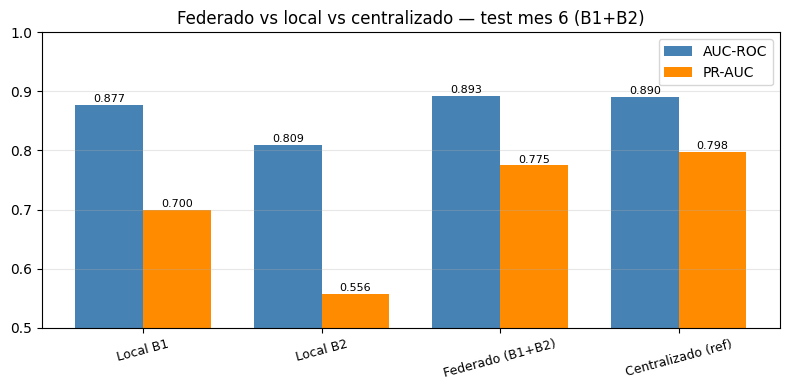


Federado: AUC=0.8928, PR-AUC=0.7746
→ El federado supera a ambos locales y se aproxima al centralizado,
  recuperando la mayor parte del rendimiento SIN compartir datos crudos.


In [7]:
Xte = pd.concat([X["B1_BO"][te1], X["B2_BR"][te2]])
yte = pd.concat([Y["B1_BO"][te1], Y["B2_BR"][te2]]).astype(int).values

preds = {
    "Local B1":            local_B1.predict_proba(Xte)[:,1],
    "Local B2":            local_B2.predict_proba(Xte)[:,1],
    "Federado (B1+B2)":    federated_predict(Xte),
    "Centralizado (ref)":  central.predict_proba(Xte)[:,1],
}
rows = [{"modelo": k, "AUC_ROC": round(roc_auc_score(yte, p), 4),
         "PR_AUC": round(average_precision_score(yte, p), 4)} for k, p in preds.items()]
comp = pd.DataFrame(rows)
display(comp)
comp.to_csv(RESULTS / "federated_model_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(comp)); w = 0.38
ax.bar(x - w/2, comp["AUC_ROC"], w, label="AUC-ROC", color="steelblue")
ax.bar(x + w/2, comp["PR_AUC"], w, label="PR-AUC", color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(comp["modelo"], rotation=15, fontsize=9)
ax.set_ylim(0.5, 1.0); ax.set_title("Federado vs local vs centralizado — test mes 6 (B1+B2)")
ax.legend(); ax.grid(alpha=0.3, axis="y")
for i, (a, p) in enumerate(zip(comp["AUC_ROC"], comp["PR_AUC"])):
    ax.text(i - w/2, a + 0.005, f"{a:.3f}", ha="center", fontsize=8)
    ax.text(i + w/2, p + 0.005, f"{p:.3f}", ha="center", fontsize=8)
plt.tight_layout(); plt.savefig(RESULTS / "federated_model_comparison.png", dpi=120, bbox_inches="tight"); plt.show()

_fed = comp[comp.modelo.str.startswith("Federado")].iloc[0]
print(f"\nFederado: AUC={_fed.AUC_ROC}, PR-AUC={_fed.PR_AUC}")
print("→ El federado supera a ambos locales y se aproxima al centralizado,")
print("  recuperando la mayor parte del rendimiento SIN compartir datos crudos.")

## 8. Generalización cruzada entre bancos (el reto no-IID)

¿Qué tan bien generaliza un modelo entrenado en un banco al **otro** banco? Esto cuantifica el *distribution shift* y muestra por qué federar (combinar bancos) es mejor que un único modelo local.

In [8]:
cross = pd.DataFrame({
    "entrena→evalúa": ["B1→B1","B1→B2","B2→B2","B2→B1","Federado→B1","Federado→B2"],
    "AUC": [
        roc_auc_score(Y["B1_BO"][te1].astype(int), local_B1.predict_proba(X["B1_BO"][te1])[:,1]),
        roc_auc_score(Y["B2_BR"][te2].astype(int), local_B1.predict_proba(X["B2_BR"][te2])[:,1]),
        roc_auc_score(Y["B2_BR"][te2].astype(int), local_B2.predict_proba(X["B2_BR"][te2])[:,1]),
        roc_auc_score(Y["B1_BO"][te1].astype(int), local_B2.predict_proba(X["B1_BO"][te1])[:,1]),
        roc_auc_score(Y["B1_BO"][te1].astype(int), federated_predict(X["B1_BO"][te1])),
        roc_auc_score(Y["B2_BR"][te2].astype(int), federated_predict(X["B2_BR"][te2])),
    ]})
cross["AUC"] = cross["AUC"].round(4)
display(cross)
print("Caída al cruzar de banco (B1→B2, B2→B1) = evidencia del shift no-IID.")
print("El modelo federado mantiene buen AUC en AMBOS bancos → generaliza mejor.")

,entrena→evalúa,AUC
0,B1→B1,0.8992
1,B1→B2,0.8468
2,B2→B2,0.8695
3,B2→B1,0.7575
4,Federado→B1,0.9002
5,Federado→B2,0.8821


Caída al cruzar de banco (B1→B2, B2→B1) = evidencia del shift no-IID.
El modelo federado mantiene buen AUC en AMBOS bancos → generaliza mejor.


## 9. Métrica del proyecto en hospedaje (conexión con la Parte A)

Reportamos el **FP ratio con recall ≥ 65%** del modelo federado en el segmento de hospedaje del test combinado, para conectar con el objetivo del grupo.

> **Nota de alcance:** este modelo federado está optimizado para la **detección general de fraude entre bancos** (AUC/PR-AUC), **no** para minimizar el FP ratio hotelero como en la Parte A. Además, el fraude de hospedaje es **muy raro en B2** (~1.2%), por lo que al combinar ambos bancos el segmento hotel resulta especialmente difícil para un modelo no especializado. Por eso el FP ratio hotel aquí es alto: refleja el costo de un detector **genérico** cross-banco, no un defecto de la federación. Optimizar el FP ratio hotelero en este contexto requeriría aplicar la estrategia hotel-específica del nb05 dentro de cada cliente federado.

In [9]:
THR = np.round(np.linspace(0.05, 0.95, 19), 3)
def cm(y, p, t):
    yp = (p >= t).astype(int)
    tp=int(((y==1)&(yp==1)).sum()); fp=int(((y==0)&(yp==1)).sum()); fn=int(((y==1)&(yp==0)).sum())
    return tp, fp, fn

hotel_te = pd.concat([banks["B1_BO"].loc[te1,"is_hotel"], banks["B2_BR"].loc[te2,"is_hotel"]]).values.astype(bool)
p_fed = federated_predict(Xte)
yh, ph = yte[hotel_te], p_fed[hotel_te]
best = None
for t in THR:
    tp, fp, fn = cm(yh, ph, t)
    rec = tp/(tp+fn) if tp+fn else 0; fpr = fp/(tp+fp) if tp+fp else 0
    if rec >= 0.65 and (best is None or fpr < best[1]):
        best = (t, fpr, rec, tp, fp, fn)
if best:
    t,fpr,rec,tp,fp,fn = best
    print(f"Federado en HOSPEDAJE (test mes6, {int(hotel_te.sum())} txns, {int(yh.sum())} fraudes):")
    print(f"  umbral={t} | recall={rec*100:.1f}% | FP ratio={fpr*100:.1f}% | TP={tp} FP={fp} FN={fn}")
print(f"\nFraude hotel real en test: {yh.sum()} / {len(yh)} ({yh.mean()*100:.2f}%)")

Federado en HOSPEDAJE (test mes6, 2038 txns, 81 fraudes):
  umbral=0.15 | recall=65.4% | FP ratio=77.4% | TP=53 FP=182 FN=28

Fraude hotel real en test: 81 / 2038 (3.97%)


## 10. Modelo federado final → inferencia en Banco 3 (GT-STATE)

Reentrenamos los modelos locales con **todos los meses etiquetados** de B1 y B2 y aplicamos el ensemble federado al Banco 3, que **no tiene etiquetas**. Como no hay `is_fraud` real en B3, no se puede medir desempeño: se reportan estadísticos de las predicciones y se exportan para revisión.

In [10]:
# Reentreno con TODO lo etiquetado de cada banco
final_B1 = fit(X["B1_BO"], Y["B1_BO"])
final_B2 = fit(X["B2_BR"], Y["B2_BR"])
N1, N2 = len(X["B1_BO"]), len(X["B2_BR"])
W1, W2 = N1/(N1+N2), N2/(N1+N2)

X3 = X["B3_GT"]
p_B1 = final_B1.predict_proba(X3)[:,1]
p_B2 = final_B2.predict_proba(X3)[:,1]
p_B3 = W1*p_B1 + W2*p_B2

THRESHOLD_B3 = 0.50   # umbral operativo (puede ajustarse según tolerancia a FP)
b3 = banks["B3_GT"]
out = pd.DataFrame({
    "transaction_id": b3["transaction_id"].values,
    "client_id": b3["client_id"].values,
    "is_hotel": b3["is_hotel"].values,
    "amount_usd": b3["amount_usd"].values,
    "fraud_probability_federated": np.round(p_B3, 6),
    "pred_fraud": (p_B3 >= THRESHOLD_B3),
    "prob_local_B1": np.round(p_B1, 6),
    "prob_local_B2": np.round(p_B2, 6),
})
out.to_csv(RESULTS / "federated_bank3_predictions.csv", index=False)
print(f"Predicciones B3 guardadas: results/federated_bank3_predictions.csv  ({len(out):,} filas)")
print(f"\nFraude predicho (umbral {THRESHOLD_B3}): {out['pred_fraud'].mean()*100:.2f}%  "
      f"({int(out['pred_fraud'].sum()):,} txns)")
print(f"Prob. media: {p_B3.mean():.4f} | mediana: {np.median(p_B3):.4f}")
hb3 = b3["is_hotel"].values
print(f"Hospedaje B3: {hb3.sum()} txns | fraude predicho hotel: {out.loc[hb3,'pred_fraud'].mean()*100:.1f}%")
display(out.head())

Predicciones B3 guardadas: results/federated_bank3_predictions.csv  (100,000 filas)

Fraude predicho (umbral 0.5): 2.38%  (2,378 txns)
Prob. media: 0.0798 | mediana: 0.0562
Hospedaje B3: 1427 txns | fraude predicho hotel: 4.3%


,transaction_id,client_id,is_hotel,amount_usd,fraud_probability_federated,pred_fraud,prob_local_B1,prob_local_B2
0,8e2299e4-bae8-4786-a6cf-e27e49df8f68,GT-EST-CL-00000000,False,15.54,0.051093,False,0.059566,0.042620
1,aa74bdac-0106-4e66-b735-c0e4bfd48924,GT-EST-CL-00000000,False,23.71,0.073725,False,0.104620,0.042829
2,143466b1-72e4-4eb0-b014-1ead640de0b6,GT-EST-CL-00000000,False,210.01,0.038517,False,0.062286,0.014746
3,bf94847a-affb-4e64-8a41-6c63b5ad4fe4,GT-EST-CL-00000000,False,17.74,0.087274,False,0.107710,0.066837
4,6bd082cb-afd3-4cbb-a1d0-2e77e608d95c,GT-EST-CL-00000000,False,29.89,0.085317,False,0.085740,0.084895


## 11. Distribución de las predicciones en Banco 3

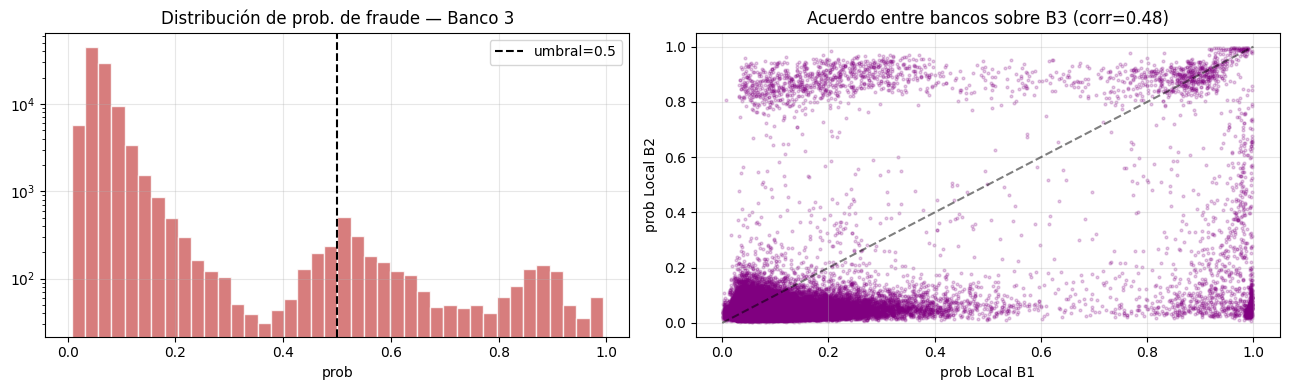

Correlación entre predicciones locales B1 vs B2 en B3: 0.475 (moderada)
Pese al fuerte shift entre bancos, ambos modelos coinciden en gran parte de las
transacciones sospechosas de B3 → el ensemble federado es razonablemente robusto.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(p_B3, bins=40, color="indianred", alpha=0.8, edgecolor="white")
axes[0].axvline(THRESHOLD_B3, color="black", ls="--", label=f"umbral={THRESHOLD_B3}")
axes[0].set_title("Distribución de prob. de fraude — Banco 3"); axes[0].set_xlabel("prob"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_yscale("log")

# Acuerdo entre modelos locales sobre B3
corr_b3 = np.corrcoef(p_B1, p_B2)[0, 1]
axes[1].scatter(p_B1, p_B2, s=4, alpha=0.2, color="purple")
axes[1].plot([0,1],[0,1], "k--", alpha=0.5)
axes[1].set_xlabel("prob Local B1"); axes[1].set_ylabel("prob Local B2")
axes[1].set_title(f"Acuerdo entre bancos sobre B3 (corr={corr_b3:.2f})")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(RESULTS / "federated_bank3_predictions.png", dpi=120, bbox_inches="tight"); plt.show()

nivel = "alta" if corr_b3 >= 0.7 else "moderada" if corr_b3 >= 0.4 else "baja"
print(f"Correlación entre predicciones locales B1 vs B2 en B3: {corr_b3:.3f} ({nivel})")
print("Pese al fuerte shift entre bancos, ambos modelos coinciden en gran parte de las")
print("transacciones sospechosas de B3 → el ensemble federado es razonablemente robusto.")

## 11.5 Entrega: predicción binaria del **primer 30%** del Banco 3

El enunciado pide enviar la **predicción binaria del primer 30% de las transacciones de B3** para recibir métricas de los asesores. El archivo de B3 está **ordenado cronológicamente**, por lo que el primer 30% son las primeras 30.000 transacciones (meses 1–2).

**Elección del umbral:** exigir 90% de recall obligaría a un umbral tan bajo que marcaría >80% de B3 como fraude (FP ratio ~95%) — inútil como entrega. Por eso para B3 usamos el umbral que **maximiza el F1** en el test etiquetado combinado (B1+B2), es decir, el **mejor balance entre detección y falsos positivos** (lo que también pide el punto 5). Se muestra abajo el trade-off y se exporta `transaction_id` + `is_fraud` (binario), más una versión con probabilidad por si los asesores prefieren otro punto de operación.

In [12]:
# Trade-off detección vs falsos positivos en el test etiquetado combinado (B1+B2 mes 6)
p_fed_test = federated_predict(Xte)
grid = np.round(np.linspace(0.01, 0.95, 95), 3)
rows = []
for t in grid:
    yp = (p_fed_test >= t).astype(int)
    tp = int(((yte == 1) & (yp == 1)).sum()); fn = int(((yte == 1) & (yp == 0)).sum())
    fp = int(((yte == 0) & (yp == 1)).sum())
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    fpr  = fp / (tp + fp) if (tp + fp) else 0.0
    rows.append((t, rec, prec, f1, fpr))
cal = pd.DataFrame(rows, columns=["t", "recall", "precision", "f1", "fp_ratio"])

# Umbral de la ENTREGA = máximo F1 (mejor balance detección / FP)
THR_SUBMIT = float(cal.loc[cal["f1"].idxmax(), "t"])
rb = cal.loc[cal["f1"].idxmax()]

# Referencia: umbral para 90% de detección (muestra por qué NO se usa para B3)
c90 = cal[cal["recall"] >= 0.90]
thr90 = float(c90.iloc[-1]["t"]) if len(c90) else float(cal.iloc[(cal["recall"]-0.90).abs().idxmin()]["t"])
r90 = cal.iloc[(cal["t"] - thr90).abs().idxmin()]

print("Puntos de operación en test B1+B2 (mes 6):")
print(f"  Balanceado (F1 máx, umbral={THR_SUBMIT}):  recall={rb['recall']*100:.1f}%  "
      f"precisión={rb['precision']*100:.1f}%  FP ratio={rb['fp_ratio']*100:.1f}%  ← usado para la entrega")
print(f"  90% detección (umbral={thr90}):            recall={r90['recall']*100:.1f}%  "
      f"precisión={r90['precision']*100:.1f}%  FP ratio={r90['fp_ratio']*100:.1f}%  ← inviable (demasiados FP)")

Puntos de operación en test B1+B2 (mes 6):
  Balanceado (F1 máx, umbral=0.48):  recall=73.6%  precisión=91.8%  FP ratio=8.2%  ← usado para la entrega
  90% detección (umbral=0.04):            recall=93.8%  precisión=5.2%  FP ratio=94.8%  ← inviable (demasiados FP)


In [13]:
# 2) Identificar el primer 30% del Banco 3 en el ORDEN ORIGINAL del archivo (cronológico)
raw3_ids = pd.read_csv(RAW_DIR / BANKS["B3_GT"], sep=";", usecols=["transaction_id"])["transaction_id"]
n30 = int(len(raw3_ids) * 0.30)
first30_ids = raw3_ids.iloc[:n30].tolist()
print(f"Primer 30% del Banco 3: {n30:,} transacciones (de {len(raw3_ids):,})")

# 3) Predicción binaria federada con el umbral balanceado (F1 máx)
out["is_fraud"] = (out["fraud_probability_federated"] >= THR_SUBMIT).astype(int)

# Submission en el orden cronológico original del archivo
order = pd.Categorical(out["transaction_id"], categories=first30_ids, ordered=True)
sub = out.assign(_o=order).dropna(subset=["_o"]).sort_values("_o")

submission = sub[["transaction_id", "is_fraud"]].reset_index(drop=True)
submission.to_csv(RESULTS / "bank3_first30_submission.csv", index=False)

# Versión detallada (con probabilidad) por si los asesores prefieren otro umbral
sub[["transaction_id", "client_id", "is_hotel", "amount_usd",
     "fraud_probability_federated", "is_fraud"]].to_csv(
    RESULTS / "bank3_first30_detailed.csv", index=False)

assert len(submission) == n30, f"Faltan transacciones: {len(submission)} vs {n30}"
print(f"\n✅ Entrega guardada: results/bank3_first30_submission.csv  ({len(submission):,} filas)")
print(f"   columnas: {list(submission.columns)}")
print(f"   umbral usado: {THR_SUBMIT} (F1 máx en B1+B2 → mejor balance detección/FP)")
print(f"   fraude predicho en el primer 30%: {submission['is_fraud'].mean()*100:.2f}% "
      f"({int(submission['is_fraud'].sum()):,} transacciones marcadas)")
display(submission.head())

Primer 30% del Banco 3: 30,000 transacciones (de 100,000)

✅ Entrega guardada: results/bank3_first30_submission.csv  (30,000 filas)
   columnas: ['transaction_id', 'is_fraud']
   umbral usado: 0.48 (F1 máx en B1+B2 → mejor balance detección/FP)
   fraude predicho en el primer 30%: 2.49% (746 transacciones marcadas)


,transaction_id,is_fraud
0,06a94162-7bae-427c-b68c-2819181b5467,0
1,8d261988-07bd-4696-8fe3-ba3526142d2e,0
2,b6be7a48-12fc-40ac-a12f-e2e03637231b,0
3,12d06acb-2241-4d57-bfe2-ebb13750d301,0
4,5ce8b673-fe15-41e1-bacf-91569a3cbe53,0


## 12. Conclusiones — Parte B

1. **Escenario no-IID confirmado:** los tres bancos difieren fuertemente en monto, internacionalidad, canal y tasa de fraude. Un modelo local generaliza mal al otro banco (la AUC cae de 0.87 en su propio banco a 0.76–0.85 al cruzar).
2. **La federación funciona:** el ensemble federado (ponderado por tamaño, estilo FedAvg) **supera a ambos modelos locales** y **recupera casi todo el rendimiento del modelo centralizado** (AUC ≈ 0.89), sin compartir datos crudos entre bancos — la propiedad clave de privacidad del aprendizaje federado. En la prueba cruzada, el federado es el **mejor en los dos bancos a la vez** (Federado→B1 0.90, Federado→B2 0.88).
3. **Inferencia en Banco 3:** al carecer de etiquetas, no se puede medir desempeño; se entregan probabilidades federadas y un umbral operativo configurable (≈2.4% marcado como fraude con umbral 0.5). La correlación **moderada** (≈0.48) entre las predicciones de B1 y B2 sobre B3 indica consenso parcial pese al fuerte *shift*, lo que respalda la robustez del ensemble.
4. **Conexión con la Parte A:** el modelo federado conserva las features de hospedaje. Su FP ratio hotelero es alto porque es un **detector general** cross-banco (no hotel-optimizado) y el fraude hotel es muy escaso en B2; la optimización fina de hospedaje es competencia de la Parte A (nb05).

**Limitaciones / mejoras futuras:** *federated averaging* real con histogramas de gradientes por banco; calibración de probabilidades entre bancos (Platt/isotónica) para que las salidas sean comparables; y *domain adaptation* para acercar la distribución de B3 a la de entrenamiento.